In [1]:
import os

os.chdir("..")
print(os.getcwd())

import sys
from pathlib import Path
from importlib import reload

import utils.paths as paths

/hs/fs08/data/group-brueggen/tmartinez/diffusion/src


# Deconvolution

In [2]:
from data.sets.datasets import LOFARPrototypesDataset

dset = LOFARPrototypesDataset("prototypes", train_mode=False, img_size=80)

10:27:04 - INFO (data.sets.image_path_dataset): Loading images from 'images'...
10:27:11 - INFO (data.sets.image_path_dataset): Loading names from catalog...
10:27:13 - INFO (data.sets.image_path_dataset): Loading 'masks'...
10:27:21 - INFO (data.sets.image_path_dataset): Data set initialized.
10:27:21 - INFO (data.sets.image_path_dataset): Loading mask metadata...
10:27:21 - INFO (data.sets.image_path_dataset): Image size 80: Removing sources with model_radius > 40.0...
10:27:21 - INFO (data.sets.image_path_dataset): Removed 571 of 23_817 sources (2.4%).
10:27:21 - INFO (data.sets.image_path_dataset): Reshaping images...
10:27:21 - INFO (data.sets.image_path_dataset): Reshaping masks...
10:27:21 - INFO (data.sets.image_path_dataset): Attribute 'mask_sizes' transformed with Box-Cox transformation.
Lambdas: [-0.59550307].


In [3]:
import numpy as np

n_img = 16
idxs = np.random.choice(len(dset), n_img, replace=False)
imgs_raw = dset.data[idxs].unsqueeze(1)

## Deblurrer Deconvolution

In [4]:
import models.deblur.deblurrer

reload(models.deblur.deblurrer)
from models.deblur.deblurrer import Deblurrer

parent = paths.MODEL_PARENT / "Deblurrer_HaloLoss/lightning"

ckpt = sorted(list(parent.glob("best-*")))[-1]

model = Deblurrer.load_from_checkpoint(ckpt)

In [5]:
import torch

device = "cuda:1"
model.to(device)
model.eval()

imgs = imgs_raw * 2 - 1
imgs = imgs.to(device)
with torch.no_grad():
    out = (model(imgs) + 1) / 2

out_reblur = model.blur(out)
resid = out_reblur - (imgs + 1) / 2

imgs = (imgs.cpu().numpy().squeeze() + 1) / 2
out_reblur = out_reblur.cpu().numpy().squeeze()
out = out.cpu().numpy().squeeze()
resid = resid.cpu().numpy().squeeze()
out_reblur_sc = out_reblur / out_reblur.max(axis=(1, 2), keepdims=True)
resid_sc = out_reblur_sc - imgs

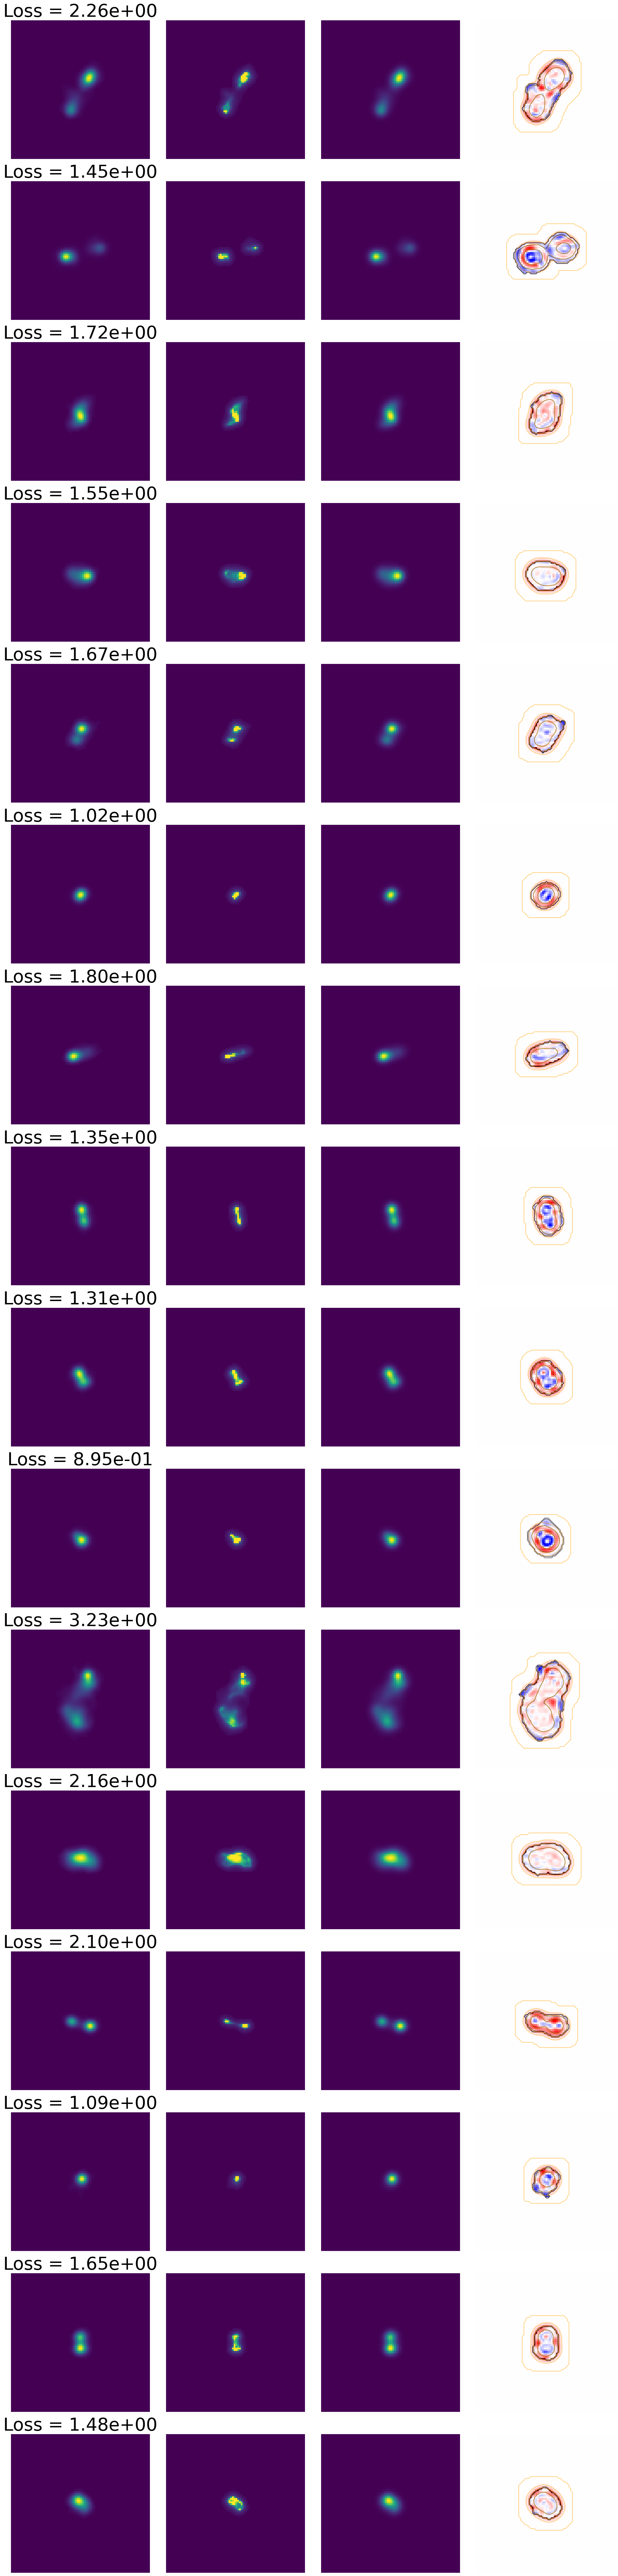

In [ ]:
import matplotlib.pyplot as plt

n_plot = 16
idxs = np.random.choice(n_img, n_plot, replace=False)
fig, axs = plt.subplots(n_plot, 4, figsize=(5 * 4, 5 * n_plot), tight_layout=True)

axs = axs.T
log = False
kw = dict(vmin=0, vmax=1)
for i, j in enumerate(idxs):
    axs[0, i].set_title(f"Loss = {np.abs(resid[j]).sum():.2e}", fontsize=40)
    axs[0, i].imshow(np.log(imgs[j]) if log else imgs[j], **({} if log else kw))
    axs[1, i].imshow(np.log(out[j]) if log else out[j], **({} if log else kw))
    axs[2, i].imshow(
        np.log(out_reblur_sc[j]) if log else out_reblur_sc[j], **({} if log else kw)
    )
    absmax = np.max(np.abs(resid[j]))
    axs[3, i].imshow(resid_sc[j], vmin=-absmax, vmax=absmax, cmap="bwr")
    # axs[3, i].imshow(np.log(out_reblur_sc[j]) if log else out_reblur_sc[j], **({} if log else kw), cmap='Greys_r', alpha=0.5)
    axs[3, i].contour(
        np.log(imgs[j]) if log else imgs[j],
        levels=[0, 1e-3, 1e-2, 1e-1],
        colors="k",
        alpha=0.5,
    )
    axs[3, i].contour(
        np.log(out_reblur_sc[j]) if log else out_reblur_sc[j],
        levels=[0, 1e-3, 1e-2, 1e-1],
        colors="orange",
        alpha=0.5,
    )


for ax in axs.ravel():
    ax.axis("off")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.widgets as widgets
import numpy as np


def interactive_image_profile_widget(
    img1, img2, img1_title="Image 1", img2_title="Image 2", log=False
):
    """
    Create an interactive widget with line profiles and images with slice indicators.

    Parameters
    ----------
    img1 : numpy.ndarray
        First image (2D array)
    img2 : numpy.ndarray
        Second image (2D array)
    img1_title : str
        Title for first image
    img2_title : str
        Title for second image
    """
    # Ensure images are numpy arrays
    if hasattr(img1, "cpu"):  # Handle torch tensors
        img1 = img1.cpu().numpy()
    if hasattr(img2, "cpu"):
        img2 = img2.cpu().numpy()

    # Handle batch dimensions - take first image if batched
    if img1.ndim > 2:
        img1 = img1.squeeze()
        if img1.ndim > 2:
            img1 = img1[0] if img1.shape[0] < img1.shape[-1] else img1[..., 0]
    if img2.ndim > 2:
        img2 = img2.squeeze()
        if img2.ndim > 2:
            img2 = img2[0] if img2.shape[0] < img2.shape[-1] else img2[..., 0]

    # Get image dimensions
    h1, w1 = img1.shape
    h2, w2 = img2.shape

    # Create figure with custom layout
    fig = plt.figure(figsize=(12, 6))

    # Create subplots: profile plot on left, images and controls on right
    gs = fig.add_gridspec(4, 3, width_ratios=[2, 1, 1], height_ratios=[1, 1, 0.1, 0.1])

    # Profile plot spans all rows on the left
    ax_profile = fig.add_subplot(gs[:, 0])

    # Images on top right
    ax_img1 = fig.add_subplot(gs[0, 1])
    ax_img2 = fig.add_subplot(gs[0, 2])

    # Slider below images, spanning both columns
    ax_slider = fig.add_subplot(gs[2, 1:])

    # Buttons below slider
    ax_button_down = fig.add_subplot(gs[3, 1])
    ax_button_up = fig.add_subplot(gs[3, 2])

    # Display images with 1:1 aspect ratio and no ticks/labels
    im1 = ax_img1.imshow(img1, aspect="equal")
    im2 = ax_img2.imshow(img2, aspect="equal")

    # Configure image axes
    for ax, title in [(ax_img1, img1_title), (ax_img2, img2_title)]:
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Initial slice position (middle of smaller image)
    initial_slice = min(h1, h2) // 2

    # Create slider with integer steps
    slider = widgets.Slider(
        ax_slider,
        "Y",
        0,
        min(h1, h2) - 1,
        valinit=initial_slice,
        valfmt="%d",
        valstep=1,
    )

    # Create step buttons
    button_down = widgets.Button(ax_button_down, "▼")
    button_up = widgets.Button(ax_button_up, "▲")

    # Initialize line plots and slice indicators
    (line1,) = ax_profile.plot([], [], "b-", linewidth=2, label=img1_title)
    (line2,) = ax_profile.plot([], [], "r-", linewidth=2, label=img2_title)

    # Red lines indicating slice position
    slice_line1 = ax_img1.axhline(y=initial_slice, color="red", linewidth=2, alpha=0.5)
    slice_line2 = ax_img2.axhline(y=initial_slice, color="red", linewidth=2, alpha=0.5)

    ax_profile.set_xlabel("X Position")
    ax_profile.set_ylabel("Intensity")
    ax_profile.set_title("Horizontal Profile Comparison")
    ax_profile.legend()
    ax_profile.grid(True, alpha=0.3)
    # Set fixed y range
    if log:
        ax_profile.set_yscale("log")
    ax_profile.set_ylim(0 if not log else 1e-9, max(img1.max(), img2.max()) * 1.05)

    def update_plot(slice_y):
        """Update the profile plot and slice indicators"""
        slice_y = int(slice_y)

        # Extract horizontal slices
        if slice_y < h1:
            profile1 = img1[slice_y, :]
            x1 = np.arange(len(profile1))
            line1.set_data(x1, profile1)
        else:
            line1.set_data([], [])

        if slice_y < h2:
            profile2 = img2[slice_y, :]
            x2 = np.arange(len(profile2))
            line2.set_data(x2, profile2)
        else:
            line2.set_data([], [])

        # Update slice indicators
        if slice_y < h1:
            slice_line1.set_ydata([slice_y, slice_y])
        if slice_y < h2:
            slice_line2.set_ydata([slice_y, slice_y])

        # Only rescale x-axis, keep y-axis fixed
        ax_profile.relim()
        ax_profile.autoscale_view(scalex=True, scaley=False)

        fig.canvas.draw_idle()

    # Button callback functions
    def step_down(event):
        current_val = slider.val
        new_val = max(current_val - 1, slider.valmin)
        slider.set_val(new_val)

    def step_up(event):
        current_val = slider.val
        new_val = min(current_val + 1, slider.valmax)
        slider.set_val(new_val)

    # Connect slider and buttons to update function
    slider.on_changed(update_plot)
    button_down.on_clicked(step_down)
    button_up.on_clicked(step_up)

    # Initial plot update
    update_plot(initial_slice)

    plt.tight_layout()
    return fig, slider, button_down, button_up


# Example usage with your deblurrer outputs:
def plot_deblurrer_comparison(x, x_hat, slice_pos=None, log=False):
    """
    Convenience function for comparing input and deblurred images

    Parameters
    ----------
    x : torch.Tensor or numpy.ndarray
        Input (blurred) image
    x_hat : torch.Tensor or numpy.ndarray
        Deblurred image output
    slice_pos : int, optional
        Initial slice position
    """
    return interactive_image_profile_widget(
        x, x_hat, img1_title="Input (Blurred)", img2_title="Deblurred Output", log=log
    )

In [ ]:
# Create the interactive widget
i = 3
%matplotlib widget
fig, slider, button_down, button_up = plot_deblurrer_comparison(imgs[i], out_reblur_sc[i], log=True)  # Compare first images in batch
plt.show()

In [67]:
"%percent"

'%percent'

In [ ]:
# Adaptive fft loss:

img = torch.from_numpy(out).unsqueeze(1)
orig_img = torch.from_numpy(imgs).unsqueeze(1)
eps = 1e-3

N, C, H, W = img.shape

# Brightness map (grayscale proxy)
brightness = img.mean(dim=1, keepdim=True)  # (N,1,H,W)

# ---- FFT ----
fft = torch.fft.fft2(img, dim=(-2, -1))
fft_shift = torch.fft.fftshift(fft, dim=(-2, -1))

# Frequency weighting mask (radial ramp)
yy, xx = torch.meshgrid(
    torch.linspace(-0.5, 0.5, H, device=img.device),
    torch.linspace(-0.5, 0.5, W, device=img.device),
    indexing="ij",
)
freq_radius = torch.sqrt(xx**2 + yy**2)  # 0 at center, max ~0.7 at corners
freq_weight = freq_radius.unsqueeze(0).unsqueeze(0) ** 0.25  # shape (1,1,H,W)
freq_weight = freq_weight / freq_weight.max()
plt.plot(freq_weight[0, 0, 40])
plt.show()

# Apply high-pass weighting
fft_filtered = fft_shift * freq_weight

# Undo shift & inverse FFT back to spatial domain
fft_unshift = torch.fft.ifftshift(fft_filtered, dim=(-2, -1))
high_freq_map = torch.fft.ifft2(fft_unshift, dim=(-2, -1)).real

# Penalize high frequencies more in dark areas
penalty_map = torch.abs(high_freq_map) * (1.0 / (brightness + eps))

In [ ]:
import matplotlib.pyplot as plt

n_plot = 16
fig, axs = plt.subplots(n_plot, 4, figsize=(5 * 4, 5 * n_plot), tight_layout=True)

axs = axs.T
for i, j in enumerate(idxs):
    axs[0, i].set_title(f"Loss = {np.abs(resid[j]).sum():.2e}", fontsize=40)
    axs[0, i].imshow(imgs[j], vmin=0, vmax=1)
    axs[1, i].imshow(out[j])
    # axs[2, i].imshow(np.log(out[j]), cmap='Greys')
    axs[2, i].imshow(high_freq_map.squeeze()[j], cmap="Reds", alpha=0.7)
    axs[3, i].imshow(np.log(out[j]), cmap="Greys")
    axs[3, i].imshow(penalty_map.squeeze()[j], cmap="Reds", alpha=0.7)

for ax in axs.ravel():
    ax.axis("off")

In [ ]:
orig_img.min()

In [ ]:
import matplotlib.pyplot as plt

n_plot = 16

scaled_maps = img / (orig_img**2 + 5e-4)
fig, axs = plt.subplots(n_plot, 4, figsize=(5 * 4, 5 * n_plot), tight_layout=True)

axs = axs.T
for i, j in enumerate(idxs):
    axs[0, i].set_title(f"Loss = {np.abs(resid[j]).sum():.2e}", fontsize=40)
    axs[0, i].imshow(imgs[j], vmin=0, vmax=1)
    axs[1, i].imshow(out[j])
    # axs[2, i].imshow(np.log(out[j]), cmap='Greys')
    axs[2, i].imshow(scaled_maps.squeeze()[j], cmap="Reds", alpha=0.7)
    axs[3, i].imshow(np.log(out[j]), cmap="Greys")
    axs[3, i].imshow(scaled_maps.squeeze()[j], cmap="Reds", alpha=0.7)

for ax in axs.ravel():
    ax.axis("off")

In [ ]:
# Look at the pixel distributions of all 4 images
fig, ax = plt.subplots(1, 1, figsize=(12, 8), tight_layout=True)

hist_kw = dict(bins=100, histtype="step", alpha=0.5)
# ax.hist(imgs.ravel(), **hist_kw, color="blue", label="Input")
# ax.hist(out.ravel(), **hist_kw, color="orange", label="Output")
# ax.hist(out_reblur.ravel(), **hist_kw, color="green", label="Reblurred")
ax.hist(resid.ravel(), **hist_kw, color="red", label="Residual")
ax.hist(resid_sc.ravel(), **hist_kw, color="violet", label="Residual")

ax.set_yscale("log")
ax.set_xlabel("Pixel value")
ax.set_ylabel("Count")
ax.set_title("Pixel value distributions")
ax.legend()
ax.grid(alpha=0.3)

fig.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8), tight_layout=True)

flg = imgs != 0
kw = dict(
    s=0.3,
    alpha=0.5,
)
ax.scatter(
    imgs[flg].ravel(),
    out_reblur[flg].ravel() / imgs[flg].ravel(),
    color="blue",
    label="Reblurred vs Input",
    **kw
)
# ax.scatter(imgs[flg].ravel(), out_reblur_sc[flg].ravel() / imgs[flg].ravel(), color='orange', label="Reblurred vs Input (scaled)", **kw)
# ax.plot([0, 1], [0, 1], color='red', linestyle='--', label="y=x")

ax.set_xlabel("Input pixel value")
ax.set_ylabel("Relative Deviation")
ax.set_title("Reblurred vs Input")
ax.legend()
ax.grid(alpha=0.3)
fig.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8), tight_layout=True)

flg = imgs == 0
ax.hist(
    out_reblur[flg].ravel(),
    bins=100,
    histtype="step",
    alpha=0.5,
    color="blue",
    label="Reblurred vs Input",
)
ax.hist(
    out_reblur_sc[flg].ravel(),
    bins=100,
    histtype="step",
    alpha=0.5,
    color="orange",
    label="Reblurred vs Input (scaled)",
)

ax.set_xlabel("Input pixel value")
# ax.set_ylabel("Reblurred pixel value")
ax.set_title("Reblurred vs Input")
ax.legend()
ax.grid(alpha=0.3)
ax.set_yscale("log")
fig.show()

In [ ]:
ftot_imgs = imgs.sum(axis=(1, 2))
ftot_rec = out_reblur.sum(axis=(1, 2))
ftot_rec_sc = out_reblur_sc.sum(axis=(1, 2))

fig, ax = plt.subplots(1, 1, figsize=(10, 6), tight_layout=True)

ax.hist(
    (ftot_rec - ftot_imgs) / ftot_imgs,
    bins=25,
    histtype="step",
    alpha=0.5,
    color="blue",
    label="Total flux",
)
ax.hist(
    (ftot_rec_sc - ftot_imgs) / ftot_imgs,
    bins=25,
    histtype="step",
    alpha=0.5,
    color="orange",
    label="Total flux (scaled)",
)

ax.legend()
ax.grid(alpha=0.3)

fig.show()

In [ ]:
fpeak_rec = out_reblur.max(axis=(1, 2))

fig, ax = plt.subplots(1, 1, figsize=(10, 6), tight_layout=True)

ax.hist(
    fpeak_rec - 1, bins=10, histtype="step", alpha=0.5, color="blue", label="Total flux"
)

ax.legend()
ax.grid(alpha=0.3)

fig.show()

## Residual Deblurrer Deconvolution

In [ ]:
import models.deblurrer

reload(models.deblurrer)
from models.deblurrer import ResidualDeblurrer

parent = paths.MODEL_PARENT / "Residual_Deblurrer_weight/lightning"

ckpt = sorted(list(parent.glob("best-*")))[-1]

model = ResidualDeblurrer.load_from_checkpoint(ckpt)

In [ ]:
import torch

device = "cuda:0"
model.to(device)
model.eval()

imgs = imgs_raw * 2 - 1
imgs = imgs.to(device)
with torch.no_grad():
    out = (model(imgs) + 1) / 2

out, out_resid = out.chunk(2, dim=1)
out_reblur = model.blur(out)
resid = out_reblur - (imgs + 1) / 2

imgs = (imgs.cpu().numpy().squeeze() + 1) / 2
out_reblur = out_reblur.cpu().numpy().squeeze()
out = out.cpu().numpy().squeeze()
out_resid = out_resid.cpu().numpy().squeeze()
resid = resid.cpu().numpy().squeeze()
out_reblur_sc = out_reblur / out_reblur.max(axis=(1, 2), keepdims=True)

In [ ]:
out_reblur_sc = out_reblur / out_reblur.max(axis=(1, 2), keepdims=True)
resid_sc = out_reblur_sc - imgs

In [ ]:
import matplotlib.pyplot as plt


fig, axs = plt.subplots(5, n_img, figsize=(5 * n_img, 5 * 5), tight_layout=True)

for i in range(n_img):
    axs[0, i].set_title(f"Loss = {np.abs(resid[i]).sum():.2e}", fontsize=40)
    axs[0, i].imshow(imgs[i], vmin=0, vmax=1)
    axs[1, i].imshow(out[i])
    axs[2, i].imshow(out_reblur_sc[i], vmin=0, vmax=1)
    axs[3, i].imshow(resid_sc[i], vmin=-0.1, vmax=0.1, cmap="bwr")
    axs[4, i].imshow(out_resid[i], vmin=-0.1, vmax=0.1, cmap="bwr")


for ax in axs.ravel():
    ax.axis("off")

In [ ]:
# Look at the pixel distributions of all 4 images
fig, ax = plt.subplots(1, 1, figsize=(12, 8), tight_layout=True)

hist_kw = dict(bins=100, histtype="step", alpha=0.5)
# ax.hist(imgs.ravel(), **hist_kw, color="blue", label="Input")
# ax.hist(out.ravel(), **hist_kw, color="orange", label="Output")
# ax.hist(out_reblur.ravel(), **hist_kw, color="green", label="Reblurred")
ax.hist(resid.ravel(), **hist_kw, color="red", label="Residual")
ax.hist(resid_sc.ravel(), **hist_kw, color="violet", label="Residual")

ax.set_yscale("log")
ax.set_xlabel("Pixel value")
ax.set_ylabel("Count")
ax.set_title("Pixel value distributions")
ax.legend()
ax.grid(alpha=0.3)

fig.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8), tight_layout=True)

flg = imgs != 0
kw = dict(
    s=0.3,
    alpha=0.5,
)
ax.scatter(
    imgs[flg].ravel(),
    out_reblur[flg].ravel() / imgs[flg].ravel(),
    color="blue",
    label="Reblurred vs Input",
    **kw
)
ax.scatter(
    imgs[flg].ravel(),
    out_reblur_sc[flg].ravel() / imgs[flg].ravel(),
    color="orange",
    label="Reblurred vs Input (scaled)",
    **kw
)
# ax.plot([0, 1], [0, 1], color='red', linestyle='--', label="y=x")

ax.set_xlabel("Input pixel value")
# ax.set_ylabel("Reblurred pixel value")
ax.set_title("Reblurred vs Input")
ax.legend()
ax.grid(alpha=0.3)
fig.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8), tight_layout=True)

flg = imgs == 0
ax.hist(
    out_reblur[flg].ravel(),
    bins=100,
    histtype="step",
    alpha=0.5,
    color="blue",
    label="Reblurred vs Input",
)
ax.hist(
    out_reblur_sc[flg].ravel(),
    bins=100,
    histtype="step",
    alpha=0.5,
    color="orange",
    label="Reblurred vs Input (scaled)",
)

ax.set_xlabel("Input pixel value")
# ax.set_ylabel("Reblurred pixel value")
ax.set_title("Reblurred vs Input")
ax.legend()
ax.grid(alpha=0.3)
ax.set_yscale("log")
fig.show()

In [ ]:
(out_reblur == 0).sum(), (imgs == 0).sum(),

In [ ]:
ftot_imgs = imgs.sum(axis=(1, 2))
ftot_rec = out_reblur.sum(axis=(1, 2))
ftot_rec_sc = out_reblur_sc.sum(axis=(1, 2))

fig, ax = plt.subplots(1, 1, figsize=(10, 6), tight_layout=True)

ax.hist(
    (ftot_rec - ftot_imgs) / ftot_imgs,
    bins=10,
    histtype="step",
    alpha=0.5,
    color="blue",
    label="Total flux",
)
ax.hist(
    (ftot_rec_sc - ftot_imgs) / ftot_imgs,
    bins=10,
    histtype="step",
    alpha=0.5,
    color="orange",
    label="Total flux (scaled)",
)

ax.legend()
ax.grid(alpha=0.3)

fig.show()

In [ ]:
fpeak_rec = out_reblur.max(axis=(1, 2))

fig, ax = plt.subplots(1, 1, figsize=(10, 6), tight_layout=True)

ax.hist(
    fpeak_rec - 1, bins=10, histtype="step", alpha=0.5, color="blue", label="Total flux"
)

ax.legend()
ax.grid(alpha=0.3)

fig.show()

## Richardson-Lucy Deconvolution

In [ ]:
import matplotlib.pyplot as plt
from skimage import color, data, restoration
from maps.map_utils import gaussian_signal
from scipy.ndimage import gaussian_filter
from skimage.transform import resize, rescale
from tqdm import tqdm

f_resc = 5
# FWHM = 4
# We pass 8 because of how gaussian_signal() works
psf = gaussian_signal(f_resc * 8, convolve=False, img_size=imgs.shape[-1] * f_resc)

out_rl = np.empty((n_img, imgs.shape[-1], imgs.shape[-1]))
out_reblur_rl = np.empty_like(out_rl)

for i in tqdm(range(n_img)):
    img = imgs[i].numpy().squeeze()
    img /= img.sum()

    img_resc = rescale(
        img,
        f_resc,
        anti_aliasing=False,
    )
    img_resc /= img_resc.sum()

    img_dec = restoration.richardson_lucy(
        img_resc, psf, num_iter=100, clip=False, filter_epsilon=1e-6
    )

    img_reblur = gaussian_filter(
        img_dec,
        sigma=(4 / 2.355) * f_resc,
        mode="constant",
    )

    img_dec_backsc = rescale(img_dec, 1 / f_resc, anti_aliasing=True)

    img_reblur_backsc = rescale(img_reblur, 1 / f_resc, anti_aliasing=True)
    img_reblur_backsc /= img_reblur_backsc.max()

    out_rl[i] = img_dec_backsc
    out_reblur_rl[i] = img_reblur_backsc


resid_rl = out_reblur_rl - img

In [ ]:
out_rl.shape, out_reblur_rl.shape, resid_rl.shape

In [ ]:
import matplotlib.pyplot as plt


fig, axs = plt.subplots(4, n_img, figsize=(5 * n_img, 5 * 4), tight_layout=True)

for i in range(n_img):
    axs[0, i].set_title(f"Loss = {np.abs(resid_rl[i]).sum():.2f}", fontsize=40)
    axs[0, i].imshow(imgs[i].squeeze())
    axs[1, i].imshow(out_rl[i])
    axs[2, i].imshow(out_reblur_rl[i])
    absmax = np.max(np.abs(resid_rl[i]))
    axs[3, i].imshow(resid_rl[i], vmin=-absmax, vmax=absmax, cmap="bwr")


for ax in axs.ravel():
    ax.axis("off")

In [ ]:
from tqdm import tqdm

f_rescs = np.linspace(1, 10, 10)

img = imgs[i].numpy()
losses = []
losses2 = []
for f_resc in tqdm(f_rescs):

    img_resc = rescale(
        img,
        f_resc,
        anti_aliasing=True,
    )
    img_resc /= img_resc.sum()

    # FWHM = 4
    # We pass 8 because of how gaussian_signal() works
    psf = gaussian_signal(f_resc * 8, convolve=False, img_size=img_resc.shape[-1])

    img_dec = restoration.richardson_lucy(img_resc, psf, num_iter=100, clip=False)

    img_reblur = gaussian_filter(img_dec, sigma=(4 / 2.355) * f_resc, mode="constant")
    img_reblur /= img_reblur.sum()

    img_reblur_backsc = rescale(img_reblur, 1 / f_resc, anti_aliasing=True)

    resid = img_reblur - img_resc
    resid2 = img_reblur_backsc - img

    loss = np.abs(resid).sum()
    losses.append(loss)

    loss2 = np.abs(resid2).sum()
    losses2.append(loss2)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6), tight_layout=True)

ax.scatter(f_rescs, losses, s=5, label="Loss")
# ax.scatter(f_rescs, losses2, s=5, label="Loss2")
ax.legend()

In [ ]:
from skimage.transform import resize, rescale

img_resc = rescale(
    img,
    2,
    anti_aliasing=True,
)

img_resc.shape, img.shape

plt.imshow(img_resc)
plt.show()

# Data Selection

Data subset was created by selecting cutouts with Sigma_SNR >= 5 and by removing all broken or problematic images. We proceed from that subset.

In [ ]:
subset_file = paths.LOFAR_SUBSETS["200p"]

import h5py

with h5py.File(subset_file, "r") as f:
    # List all groups
    [print(k) for k in f.keys()]

    print(dict(f["masks_edge_thr"].attrs))

In [ ]:
# Load the data subset to start from
import data.datasets as dsets

# dsets.print_available_datasets()

# This usually takes 4-5 min
dset = dsets.ImagePathDataset("200p", train_mode=False)

In [ ]:
# Get some of the data into numpy arrays (this takes a while)
print("Transoforming images...")
images = dset.data.numpy()

print("Transforming refined masks...")
masks_refined = dset.masks_refined.numpy().astype(int)

print("Transforming edge threshold masks...")
# masks_edge_thr = dset.masks_edge_thr.numpy().astype(int)

In [ ]:
print("Transforming edge threshold masks...")
masks_edge_thr = dset.masks_edge_thr.numpy().astype(int)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from skimage.measure import label, regionprops


lables_m_refined = [label(m) for m in tqdm(masks_refined, total=len(dset))]
labels_m_edgethr = [label(m) for m in tqdm(masks_edge_thr, total=len(dset))]

In [ ]:
n_islands = dset.island_labels.numpy().max(axis=(1, 2))
n_islands_refined = [np.max(l) for l in lables_m_refined]
n_islands_edgethr = [np.max(l) for l in labels_m_edgethr]

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

hist_kw = dict(bins=range(1, 50), alpha=0.9, histtype="step")

ax.hist(n_islands, label="Original", **hist_kw)
ax.hist(n_islands_refined, label="Refined", **hist_kw)
ax.hist(n_islands_edgethr, label="Edge threshold", **hist_kw)

ax.set_xlabel("Number of islands")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)

fig.show()

In [ ]:
# Pixel value distribution
plt.hist(dset.data.numpy().flatten(), bins=100, alpha=0.9, histtype="step", log=True)

In [ ]:
from data.segment import mask_edge
from data.transforms import minmax_scale_masked


def get_edge_pixels(mask_arr):
    return [
        minmax_scale_masked(img, mask) * mask_edge(mask)
        for img, mask in tqdm(zip(images, mask_arr), total=len(dset))
    ]


print("Calculating masked images...")
masked_images = images * masks_edge_thr

print("Calculating edge pixels...")
edgepx_ref = get_edge_pixels(masks_refined)

print("Calculating edge pixels...")
edgepx_eth = get_edge_pixels(masks_edge_thr)

# Experimental

In [ ]:
import data.cutouts as cts
import data.images as imgs
import utils.paths as paths
from data.datasets import CutoutsDataset


cutout_file = paths.CUTOUTS_DIR / "cutouts_200p_optC.hdf5"
dset = CutoutsDataset(cutout_file)

In [ ]:
len(dset)

In [ ]:
dset.catalog.columns

In [ ]:
snr_subset = dset.index_sliced(dset.catalog.Sigma_SNR >= 5)

In [ ]:
len(snr_subset)

In [ ]:
from plotting.image_plots import metric_peek
import numpy as np

metric_peek(
    snr_subset.catalog.Sigma_SNR.values,
    np.linspace(0, 8, 9),
    snr_subset.data,
    metric_name="Sigma SNR",
    n_examples=20,
)

In [ ]:
images = dset.data.numpy()

from data.image_utils import sigma_snr_set

SNR = sigma_snr_set(images)

In [ ]:
SNR

In [ ]:
dset.catalog.Sigma_SNR.values

In [ ]:
from torchvision.transforms.v2 import CenterCrop

# Get sigma_snr only for inner 80px cutouts
images_crop80 = CenterCrop(80)(dset.data).numpy()

SNR_crop80 = sigma_snr_set(images_crop80)

In [ ]:
SNR_crop80

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

scatter_kw = dict(s=1, alpha=0.5)

ax = axs[0]
ax.scatter(dset.catalog.Sigma_SNR.values, SNR, **scatter_kw)
ax.set_ylabel("Sigma SNR (all pixels)")

ax = axs[1]
ax.scatter(dset.catalog.Sigma_SNR.values, SNR_crop80, **scatter_kw)
ax.set_ylabel("Sigma SNR (80px crop)")

ax = axs[2]
ax.hist(SNR, bins=100, alpha=0.9, histtype="step", label="All pixels")
ax.hist(SNR_crop80, bins=100, alpha=0.9, histtype="step", label="80px crop")
ax.hist(
    dset.catalog.Sigma_SNR.values, bins=100, alpha=0.9, histtype="step", label="Catalog"
)
ax.legend()
ax.set_yscale("log")

ax.set_xlabel("Sigma SNR (catalog)")

for ax in axs.flatten():
    ax.grid(alpha=0.3)

fig.show()

In [ ]:
from data.cutouts import scan_cutouts

cutouts_file = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/cutouts/cutouts_200p_optC.hdf5"
)
scan_cutouts(cutouts_file)

In [ ]:
import matplotlib.pyplot as plt

c, b, _ = plt.hist(dset.catalog.Edge_max, bins=100, label="all", density=True)
plt.hist(snr_subset.catalog.Edge_max, bins=b, label="SNR > 5", density=True)

plt.show()

In [ ]:
import data.images as imgs

imgs.create_subset(
    cutout_file,
    "200p-SNR5-unclipped",
    edge_thr=1,
)

In [ ]:
from plotting.plot_images import random_image_grid

random_image_grid(
    dset,
    n_cols=8,
    n_rows=3,
)

In [ ]:
import datasets.images as dsimg

reload(dsimg)
import datasets.cutouts as dscut

reload(dscut)
import pandas as pd
from utils.paths import LOFAR_RES_CAT, PLAYGROUND_DIR

cutout_file = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/cutouts/cutouts_80p_optC.hdf5"
)

# Test clipping with 0-clip
# dsimg.clip_cutouts(cutout_file, 0)

In [ ]:
import datasets.cutouts as dscut

reload(dscut)

# Test scanning cutouts
dscut.scan_cutouts(cutout_file)

In [ ]:
import h5py
import numpy as np

img_container = h5py.File(cutout_file, "r")
images = np.array(img_container["cutouts_0sigma"])
catalog = pd.read_hdf(cutout_file, key="catalog")

In [ ]:
catalog = catalog[catalog[f"Clipped_0sigma"]]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mask = (
    (catalog["Sigma_SNR"] >= 5)
    & (catalog["Edge_max"] <= 0.8)
    & (catalog["Broken_cutout"])
)
i = np.random.choice(np.argwhere(mask).flatten())

plt.imshow(images[i])
plt.axis("off")
plt.axis("tight")
plt.axis("image")

In [ ]:
from plotting.plot_images import random_image_grid

random_image_grid(images[mask], vmin=None, vmax=None, n_img=64)

In [ ]:
len(np.argwhere(mask).flatten())

In [ ]:
import datasets.images as dsimg

reload(dsimg)

dsimg.create_subset(
    cutout_file,
    "2sigma-clip",
    clip_sigma=2,
)

In [ ]:
import utils.paths as paths
import h5py
import numpy as np

cat = pd.read_hdf(cutout_file, key="catalog")

In [ ]:
cat

In [ ]:
import h5py
import numpy as np
import pandas as pd

with h5py.File(cutout_file, "r") as f:
    images = np.array(f["cutouts"])
catalog = pd.read_hdf(cutout_file, key="catalog")

In [ ]:
import pandas as pd
import numpy as np


def mixed_type_cols(catalog):
    # Assume catalog is your DataFrame
    mixed_type_columns = catalog.apply(lambda x: x.map(type).nunique() > 1)

    # Get the names of the columns with mixed data types
    mixed_type_column_names = mixed_type_columns[mixed_type_columns].index.tolist()

    # For each column with mixed data types, print the name, unique data types, counts, percentages, and an example
    for column_name in mixed_type_column_names:
        print(f"Column: {column_name}")
        type_counts = catalog[column_name].map(lambda x: str(type(x))).value_counts()
        type_percentages = type_counts / len(catalog) * 100
        for dtype, count in type_counts.items():
            percentage = type_percentages[dtype]
            # Get an example of the current type
            example = catalog[column_name][
                catalog[column_name].map(lambda x: str(type(x))) == dtype
            ].iloc[0]
            print(
                f"  Type: {dtype}, Count: {count}, Percentage: {percentage:.2f}%, Example: {example}"
            )

In [ ]:
import utils.paths as paths

dr2_cat = pd.read_csv(paths.LOFAR_RES_CAT)

In [ ]:
mixed_type_cols(dr2_cat)

In [ ]:
s = dr2_cat.loc[42]
print(type(s["RA"]))
s.to_frame().loc["RA"].dtype